In [2]:
# ============================================================
# CELL 1 — GPU Setup
# ============================================================
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detected: {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("❌ No GPU detected, running on CPU")

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("✅ Imports done")

✅ Imports done


In [4]:
# ============================================================
# CELL 3 — Explore Dataset Files
# ============================================================
import os

# Update this path to match your Kaggle dataset name
DATASET_PATH = "/kaggle/input/datasets/muhammadasad29/ember24/New folder"

print("=== Files in dataset ===")
for root, dirs, files in os.walk(DATASET_PATH):
    for f in files:
        print(os.path.join(root, f))

=== Files in dataset ===
/kaggle/input/datasets/muhammadasad29/ember24/New folder/ember24_win64_train.parquet
/kaggle/input/datasets/muhammadasad29/ember24/New folder/ember24_win64_test.parquet


In [5]:
# ============================================================
# CELL 4 — Load Train & Test Parquets
# ============================================================

TRAIN_PATH = f"{DATASET_PATH}/ember24_win64_train.parquet"  # adjust filename as needed
TEST_PATH  = f"{DATASET_PATH}/ember24_win64_test.parquet"   # adjust filename as needed

train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("\nTrain columns (first 10):", list(train_df.columns[:10]))
print("Train columns (last 5) :", list(train_df.columns[-5:]))

Train shape: (720000, 898)
Test  shape: (160000, 945)

Train columns (first 10): ['histogram_0', 'histogram_1', 'histogram_2', 'histogram_3', 'histogram_4', 'histogram_5', 'histogram_6', 'histogram_7', 'histogram_8', 'histogram_9']
Train columns (last 5) : ['section_sections_23_vsize', 'section_sections_23_size_ratio', 'section_sections_23_vsize_ratio', 'strings_string_counts_/EmbeddedFile', 'strings_string_counts_registry_key']


In [6]:
# ============================================================
# CELL 5 — Inspect Labels
# ============================================================

# Find the label column — EMBER 2024 typically uses 'label' (lowercase)
# Adjust if your parquet uses a different name
LABEL_COL = None
for col in train_df.columns:
    if col.lower() == 'label':
        LABEL_COL = col
        break

if LABEL_COL is None:
    raise ValueError("❌ Could not find label column. Print train_df.columns and set LABEL_COL manually.")

print(f"✅ Label column: '{LABEL_COL}'")
print("\nTrain label distribution:")
print(train_df[LABEL_COL].value_counts())
print("\nTest label distribution:")
print(test_df[LABEL_COL].value_counts())

✅ Label column: 'label'

Train label distribution:
label
1    360000
0    360000
Name: count, dtype: int64

Test label distribution:
label
1    80000
0    80000
Name: count, dtype: int64


In [7]:
# ============================================================
# CELL 6 — Filter Out Unlabeled Samples (label == -1)
# ============================================================

# EMBER datasets include unlabeled samples with label = -1
# Keep only labeled samples (0 = benign, 1 = malware)
train_df = train_df[train_df[LABEL_COL] != -1].reset_index(drop=True)
test_df  = test_df[test_df[LABEL_COL]  != -1].reset_index(drop=True)

print("After filtering unlabeled (-1):")
print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("\nTrain label distribution:")
print(train_df[LABEL_COL].value_counts())
print("\nTest label distribution:")
print(test_df[LABEL_COL].value_counts())

After filtering unlabeled (-1):
Train shape: (720000, 898)
Test  shape: (160000, 945)

Train label distribution:
label
1    360000
0    360000
Name: count, dtype: int64

Test label distribution:
label
1    80000
0    80000
Name: count, dtype: int64


In [8]:
# ============================================================
# CELL 7 — Create Client-1 Partition (50%, IID / balanced)
# ============================================================

# Shuffle training data with fixed seed for reproducibility
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Client-1 gets the first 50% — IID (balanced distribution)
client1_df = train_df.iloc[: int(0.5 * len(train_df))].reset_index(drop=True)

print("Client-1 shape:", client1_df.shape)
print("\nClient-1 label distribution:")
print(client1_df[LABEL_COL].value_counts())
print(f"\nClass balance: {client1_df[LABEL_COL].mean():.3f} (0.5 = perfectly balanced)")

Client-1 shape: (360000, 898)

Client-1 label distribution:
label
1    180148
0    179852
Name: count, dtype: int64

Class balance: 0.500 (0.5 = perfectly balanced)


In [9]:
# ============================================================
# CELL 8 — Prepare Features & Labels
# ============================================================

# Find common feature columns between train and test
train_feature_cols = [c for c in client1_df.columns if c != LABEL_COL]
test_feature_cols  = [c for c in test_df.columns if c != LABEL_COL]

# Keep only columns present in BOTH
feature_cols = list(set(train_feature_cols) & set(test_feature_cols))
feature_cols = sorted(feature_cols)  # sort for consistent ordering

print(f"Train features : {len(train_feature_cols)}")
print(f"Test features  : {len(test_feature_cols)}")
print(f"Common features: {len(feature_cols)}")
print(f"Dropped from train: {len(train_feature_cols) - len(feature_cols)}")
print(f"Dropped from test : {len(test_feature_cols)  - len(feature_cols)}")

X_train = client1_df[feature_cols].values.astype("float32")
y_train = client1_df[LABEL_COL].values.astype("float32")

X_test = test_df[feature_cols].values.astype("float32")
y_test = test_df[LABEL_COL].values.astype("float32")

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape)
print("y_test  shape:", y_test.shape)
print(f"\nNumber of features: {X_train.shape[1]}")

Train features : 897
Test features  : 944
Common features: 894
Dropped from train: 3
Dropped from test : 50

X_train shape: (360000, 894)
y_train shape: (360000,)
X_test  shape: (160000, 894)
y_test  shape: (160000,)

Number of features: 894


In [10]:
# ============================================================
# CELL 8.5 — Check & Fix NaN Values
# ============================================================

print("=== NaN Check ===")
train_nans = pd.DataFrame(client1_df[feature_cols]).isna().sum()
test_nans  = pd.DataFrame(test_df[feature_cols]).isna().sum()

print(f"Train - columns with NaN : {(train_nans > 0).sum()} / {len(feature_cols)}")
print(f"Test  - columns with NaN : {(test_nans  > 0).sum()} / {len(feature_cols)}")
print(f"Train - total NaN cells  : {train_nans.sum()}")
print(f"Test  - total NaN cells  : {test_nans.sum()}")

# Show which columns have NaNs
print("\nTop 10 columns with most NaNs (train):")
print(train_nans[train_nans > 0].sort_values(ascending=False).head(10))

=== NaN Check ===
Train - columns with NaN : 275 / 894
Test  - columns with NaN : 275 / 894
Train - total NaN cells  : 42811657
Test  - total NaN cells  : 19341416

Top 10 columns with most NaNs (train):
strings_string_counts_wallet        354686
strings_string_counts_/tmp/         353488
strings_string_counts_powershell    353257
section_sections_18_size_ratio      352964
section_sections_18_vsize           352964
section_sections_18_entropy         352964
section_sections_18_size            352964
section_sections_18_vsize_ratio     352964
strings_string_counts_mac_addr      352377
strings_string_counts_email_addr    352377
dtype: int64


In [11]:
# ============================================================
# CELL 9 — Fix NaNs + Feature Scaling
# ============================================================
import numpy as np

# Convert to DataFrames for easier handling
X_train_df = pd.DataFrame(client1_df[feature_cols])
X_test_df  = pd.DataFrame(test_df[feature_cols])

# Strategy: fill NaNs with column median (robust to outliers)
# Fit medians on train only, apply to both
col_medians = X_train_df.median()
X_train_df = X_train_df.fillna(col_medians)
X_test_df  = X_test_df.fillna(col_medians)

# Verify NaNs are gone
assert X_train_df.isna().sum().sum() == 0, "❌ Still NaNs in train!"
assert X_test_df.isna().sum().sum()  == 0, "❌ Still NaNs in test!"
print("✅ NaNs fixed")

# Drop any columns that are all-zero variance (constant columns)
std = X_train_df.std()
constant_cols = std[std == 0].index.tolist()
if constant_cols:
    print(f"⚠️  Dropping {len(constant_cols)} constant (zero-variance) columns")
    X_train_df = X_train_df.drop(columns=constant_cols)
    X_test_df  = X_test_df.drop(columns=constant_cols)
    feature_cols = X_train_df.columns.tolist()
else:
    print("✅ No constant columns found")

# Now scale
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype("float32")
X_test  = scaler.transform(X_test_df).astype("float32")

# Final NaN check after scaling
assert not np.isnan(X_train).any(), "❌ NaNs in X_train after scaling!"
assert not np.isnan(X_test).any(),  "❌ NaNs in X_test after scaling!"

print(f"✅ Scaling done")
print(f"  X_train mean ≈ {X_train.mean():.4f}  (should be ~0)")
print(f"  X_train std  ≈ {X_train.std():.4f}  (should be ~1)")
print(f"  Final feature count: {X_train.shape[1]}")

joblib.dump(scaler, "ember24_client1_scaler.pkl")
print("✅ Scaler saved")

✅ NaNs fixed
⚠️  Dropping 4 constant (zero-variance) columns
✅ Scaling done
  X_train mean ≈ -0.0000  (should be ~0)
  X_train std  ≈ 1.0000  (should be ~1)
  Final feature count: 890
✅ Scaler saved


In [13]:
# ============================================================
# CELL 10 — Build MLP Model
# ============================================================

n_features = X_train.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       456,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,545 (2.37 MB)

 Trainable params: 620,545 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ============================================================
# CELL 11 — Train Model
# ============================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete")

Epoch 1/30


I0000 00:00:1777850584.290234     145 service.cc:152] XLA service 0x7ca24800c1c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777850584.290270     145 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777850584.290274     145 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777850584.838921     145 cuda_dnn.cc:529] Loaded cuDNN version 91002


 45/633 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7636 - loss: 0.5174

I0000 00:00:1777850587.531768     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


633/633 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8814 - loss: 0.2952 - val_accuracy: 0.9344 - val_loss: 0.1642
Epoch 2/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9333 - loss: 0.1709 - val_accuracy: 0.9413 - val_loss: 0.1491
Epoch 3/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9391 - loss: 0.1546 - val_accuracy: 0.9444 - val_loss: 0.1373
Epoch 4/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9437 - loss: 0.1433 - val_accuracy: 0.9464 - val_loss: 0.1372
Epoch 5/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9453 - loss: 0.1379 - val_accuracy: 0.9501 - val_loss: 0.1283
Epoch 6/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9484 - loss: 0.1321 - val_accuracy: 0.9543 - val_loss: 0.1203
Epoch 7/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9514 - loss: 0.1246 - val_accuracy: 0.9551 - val_loss: 0.1157
Epoch 8/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9522 - loss: 0.1222 - val_accuracy: 0.9559 - val

In [15]:
# ============================================================
# CELL 12 — Evaluate on Test Set
# ============================================================

y_pred_prob = model.predict(X_test).ravel()
y_pred      = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)   # use probabilities, not hard labels

print("=" * 45)
print("   CLIENT-1 (EMBER 2024) — TEST RESULTS")
print("=" * 45)
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc:.4f}")
print("=" * 45)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malware"]))

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
   CLIENT-1 (EMBER 2024) — TEST RESULTS
  Accuracy : 0.8847
  F1 Score : 0.8765
  ROC-AUC  : 0.8929

Classification Report:
              precision    recall  f1-score   support

      Benign       0.84      0.95      0.89     80000
     Malware       0.94      0.82      0.88     80000

    accuracy                           0.88    160000
   macro avg       0.89      0.88      0.88    160000
weighted avg       0.89      0.88      0.88    160000



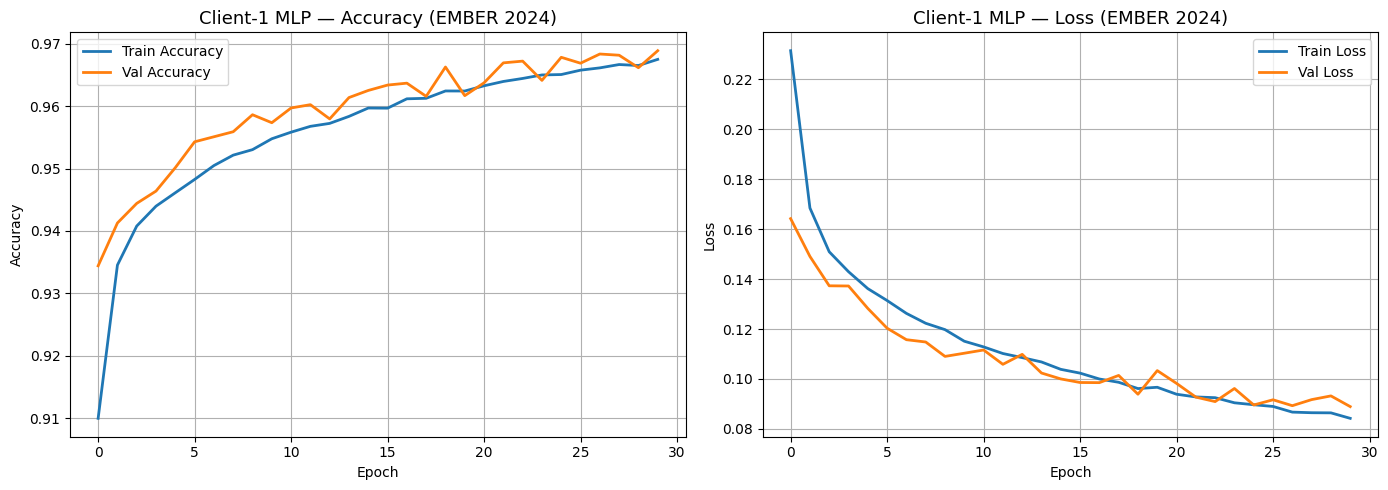

✅ Saved: client1_training_curves.png


In [16]:
# ============================================================
# CELL 13 — Training Curves Plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].set_title('Client-1 MLP — Accuracy (EMBER 2024)', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[1].set_title('Client-1 MLP — Loss (EMBER 2024)', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("client1_training_curves.png", dpi=150)
plt.show()
print("✅ Saved: client1_training_curves.png")

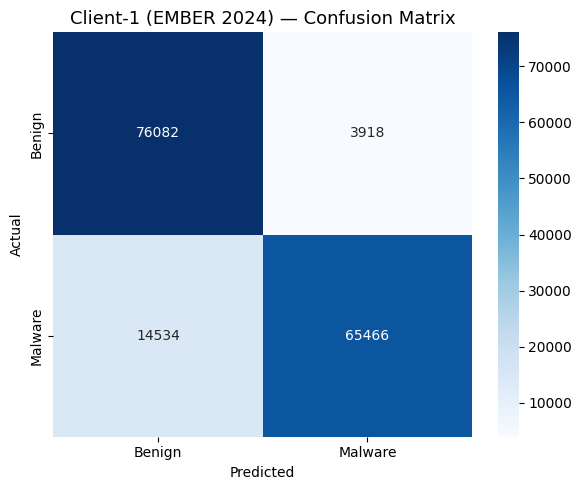

✅ Saved: client1_confusion_matrix.png


In [17]:
# ============================================================
# CELL 14 — Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Benign", "Malware"],
    yticklabels=["Benign", "Malware"]
)
plt.title("Client-1 (EMBER 2024) — Confusion Matrix", fontsize=13)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("client1_confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: client1_confusion_matrix.png")

In [17]:
# ============================================================
# CELL 15 — Save Model & Results
# ============================================================

# Save the Keras model
model.save("ember24_client1_mlp.keras")
print("✅ Model saved: ember24_client1_mlp.keras")

# Save weights separately (needed for federated averaging later)
model.save_weights("ember24_client1_weights.weights.h5")
print("✅ Weights saved: ember24_client1_weights.weights.h5")

# Save results summary to CSV
results = {
    "Client"    : ["Client-1 (MLP, IID, EMBER 2024)"],
    "Data Size" : [X_train.shape[0]],
    "Features"  : [X_train.shape[1]],
    "Accuracy"  : [round(acc, 4)],
    "F1 Score"  : [round(f1, 4)],
    "ROC-AUC"   : [round(roc, 4)],
}

pd.DataFrame(results).to_csv("client1_results.csv", index=False)
print("✅ Results saved: client1_results.csv")
print("\nSummary:")
print(pd.DataFrame(results).to_string(index=False))

✅ Model saved: ember24_client1_mlp.keras
✅ Weights saved: ember24_client1_weights.weights.h5
✅ Results saved: client1_results.csv

Summary:
                         Client  Data Size  Features  Accuracy  F1 Score  ROC-AUC
Client-1 (MLP, IID, EMBER 2024)     360000       890    0.8794    0.8688   0.8766


In [18]:
# ============================================================
# SAVE TO KAGGLE OUTPUT DIRECTORY
# ============================================================
import shutil, joblib

# Save Keras model
model.save("/kaggle/working/ember24_client1_mlp.keras")
print("✅ ember24_client1_mlp.keras")

# Save weights
model.save_weights("/kaggle/working/ember24_client1_weights.weights.h5")
print("✅ ember24_client1_weights.weights.h5")

# Save scaler
joblib.dump(scaler, "/kaggle/working/ember24_client1_scaler.pkl")
print("✅ ember24_client1_scaler.pkl")

# Save feature list (IMPORTANT — needed to align columns in FedAvg)
import json
with open("/kaggle/working/ember24_client1_feature_cols.json", "w") as f:
    json.dump(feature_cols, f)
print("✅ ember24_client1_feature_cols.json")

print("\n✅ All files saved to /kaggle/working/ — check Output tab to download")

✅ ember24_client1_mlp.keras
✅ ember24_client1_weights.weights.h5
✅ ember24_client1_scaler.pkl
✅ ember24_client1_feature_cols.json

✅ All files saved to /kaggle/working/ — check Output tab to download
